<div style="
    max-width: 99%;
    box-sizing: border-box;
    background: linear-gradient(135deg, #7f0000 0%, #b71c1c 55%, #e53935 100%);
    padding: 28px 32px;
    border-radius: 16px;
    color: #fff;
    font-family: Arial, sans-serif;
    margin-bottom: 18px;
    overflow: hidden;
">

<div style="font-size: 2.0em; font-weight: 800; margin-bottom: 6px;">
🎓 Project: 5CTA0 Statistical Signal Processing
</div>

<div style="font-size: 1em; color: #c6c6c6; margin-bottom: 14px;">
Eindhoven University of Technology (TU/e) · Department of Electrical Engineering
</div>

This is the project notebook for the 5CTA0 Statistical Signal Processing course at TU/e.

In this notebook you will apply the theory from the course to a real problem. The project is 30% of your final grade, which works out to **30% x 5.0 ECTS = 1.5 ECTS = 42 hours** of work. There are four main parts, and they generally increase in difficulty. There's also an optional bonus part at the end. Before submitting, make sure to read the instructions in the `README.md` carefully, and check the `rubric_student.md` for the grading criteria. The notebook should always run from top to bottom (you can leave cells empty if you don't know how to solve them). Good luck!
</div>

<div style="
    max-width: 99%;
    box-sizing: border-box;
    border-left: 6px solid #b71c1c;
    background: #fff6f6;
    padding: 18px 20px;
    border-radius: 10px;
    font-family: Arial, sans-serif;
    margin-bottom: 18px;
    overflow: hidden;">

  <div style="font-size: 1.5em; font-weight: 700; color: #7f0000; margin-bottom: 10px;">
    📘 Notebook Guide
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    📋 <b>Task</b><br>
    <span style="color:#5a1a1a;">Something you need to solve. Read the description, then write your work directly below it.</span>
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    🧠 <b>Your work</b><br>
    <span style="color:#5a1a1a;">
      In <b>code cells</b>: write below <code># ── 🧠 Your solution — Task X.Y ──</code>.<br>
      In <b>markdown cells</b>: replace the <em>"🧠 Your solution"</em> prompt with your explanation.<br>
      ⚠️ Do not modify any other code, and do not reorder the cells.
    </span>
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    🧠 <b>Don't know a task?</b><br>
    <span style="color:#5a1a1a;">
      Leave it as is and move on. Every answer cell ships with a <code>TODO</code> placeholder, so the
      notebook still runs <b>top to bottom</b> even when some tasks are blank. Any value you did not compute
      prints as <code>—</code>, and any figure that depends on it is skipped. A blank task only costs its own
      marks. It never breaks the run. So you can always submit a notebook that runs.
    </span>
  </div>

  <div style="margin-bottom: 4px; color: #5a1a1a;">
    📤 <b>Submission</b><br>
    <span style="color:#5a1a1a;">
      When you are finished, run <b>Kernel &rarr; Restart &amp; Run All Cells</b>, save, and upload this
      notebook to Ans. This is a group assignment, so one member submits one notebook for the whole group.
      Rename it to <code>project_group&lt;groupnumber&gt;.ipynb</code> first (for example <code>project_group12.ipynb</code>), using the group number you signed up with in Canvas.
      Leave every cell and its output in place.
    </span>
  </div>

</div>

---


<div style="
background: linear-gradient(135deg, #0d3b6e 0%, #1565c0 60%, #0277bd 100%); padding: 30px 40px; border-radius: 12px; color: white; font-family: sans-serif; margin-bottom: 10px;
max-width: 99%;
box-sizing: border-box;
overflow: hidden;
">
  <div style="display:flex; align-items:center; gap:12px; margin-bottom:8px;">
    <span style="font-size:2.2em;">🏥</span>
    <div>
      <div style="font-size:1.6em; font-weight:700; letter-spacing:0.5px;">Biomedical Signal Processing Unit</div>
      <div style="font-size:1em; color:#90caf9; font-weight:400;">Catharina Hospital Eindhoven &nbsp;·&nbsp; Department of Cardiology</div>
    </div>
  </div>
  <hr style="border:1px solid rgba(255,255,255,0.25); margin:14px 0;">
  <div style="font-size:1.3em; font-weight:600;">Patient Workup Report: VP-001, Cardiac Assessment</div>
  <div style="font-size:0.9em; color:#bbdefb; margin-top:4px;">5CTA0 Statistical Signal Processing &nbsp;·&nbsp; Clinical Project 2026</div>
</div>

### Background

You work in the **Biomedical Signal Processing (BMSP) Unit**. It sits within the Cardiology Department at Catharina Hospital Eindhoven, a referral centre for complex cardiac cases. Your team turns raw clinical data into results the cardiologists can act on. You process long ECG Holter recordings, echo image sequences, and other signals, and you provide **quantitative decision-support** to the attending cardiologists.

Today a new patient is referred to your unit. Dr. van den Berg, a consultant cardiologist, has sent **VP-001** to the BMSP team. The clinical question is:

> *"Is there a significant ventricular arrhythmia burden, and is left ventricular systolic function preserved?"*

Your task is to answer it rigorously, using the statistical signal processing methods from 5CTA0.

---

### Assignment Overview

| Part | Topic | Core 5CTA0 Concept | Points |
|------|-------|--------------------|--------|
| 1 | Data loading + R-peak detection from noisy ECG | Setup + Ch 14 (matched filter) | 10 |
| 2 | HRV: time-domain, distribution fitting, spectral analysis, time-frequency | Ch 3 (random signals) + Ch 9 (LSE) + Ch 11–13 (spectral) | 35 |
| 3 | Multi-feature arrhythmia detection | Ch 14 (Neyman-Pearson) | 25 |
| 4 | Ejection fraction estimation | Ch 6–7 (MLE, Fisher, CRLB) | 30 |
| **Bonus** | Written clinical integration report | All parts | +5.0 |
| **Bonus** | Extra candidate features in arrhythmia detection (Task 3.1) | Ch 14 (detection) | +2.5 each (≤ 2 extra), +5.0 max |

---

<div style="background: #f8f9fa; border-left: 5px solid #000000; border-radius: 6px; padding: 20px 25px; font-family: sans-serif; color: #1a1a1a; box-sizing: border-box; max-width: 99%; overflow: hidden;">

<div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
  <span style="font-size:1.8em;">🩺</span>
  <div>
    <div style="font-size:1.2em; font-weight:700; color:#0d3b6e;">Cardiology Referral: Virtual Patient VP-001</div>
    <div style="font-size:0.85em; color:#555;">Referred by Dr. A. van den Berg, MD PhD · Cardiology OPD · 22 April 2026</div>
  </div>
</div>

<hr style="border-top:1px solid rgb(0, 0, 0); margin:10px 0 14px;">

**Chief complaint:** A 65-year-old male presents with a 3-month history of *palpitations* and *mild dyspnoea on exertion*. He reports occasional lightheadedness but no syncope. Symptoms are intermittent and not related to exercise.

**Relevant history:** Hypertension (treated with ACE inhibitor for 8 years), non-smoker, no prior cardiac events.

**Physical examination:** HR 74 bpm (irregular), BP 138/86 mmHg. Heart sounds normal; no murmurs or extra sounds. Mild ankle oedema.

**Investigations requested:**
- 30-minute ambulatory Holter ECG (MIT-BIH record 119, 360 Hz)
- Resting 2D transthoracic echocardiogram (apical 2-chamber view, CAMUS dataset)

</div>

### Referral Data Summary

| Datum | Value |
|-------|-------|
| Patient ID | VP-001 |
| Age / sex | 65 y / M |
| Chief complaint | Palpitations, mild dyspnoea on exertion |
| Risk factors | Hypertension (treated) |
| ECG source | MIT-BIH Arrhythmia DB, record 119, 30 min Holter, 360 Hz |
| Echo source | CAMUS validation set, apical 2-chamber (A2C) view, 256 × 256 px |
| **Clinical question** | Is there a significant arrhythmia burden? Is LV systolic function preserved? |

### Clinical Questions for the BMSP Unit

The cardiologist wants quantitative answers to the following:

1. **Arrhythmia burden:** Are premature ventricular contractions (PVCs) present? What is the PVC burden (%)? Is it clinically significant (threshold: > 5 %)?
2. **Autonomic function:** What does the Heart Rate Variability (HRV) spectral analysis (LF/HF ratio) suggest about the patient's sympathovagal balance?
3. **Detection performance:** Can a Neyman-Pearson (NP) optimal detector reliably identify PVC beats in real time? What AUC can be achieved?
4. **LV systolic function:** What is the left ventricular ejection fraction (EF)? Is it preserved (≥ 55 %), mildly reduced (40–55 %), or reduced (< 40 %)?

Your analysis in this notebook forms the evidence behind the cardiology report.

### Abbreviations

| Abbreviation | Meaning |
|--------------|---------|
| **AR**       | Autoregressive |
| **HRV**      | Heart Rate Variability |
| **LF / HF**  | Low Frequency / High Frequency |
| **Log-LRT**  | Log-Likelihood Ratio Test |
| **LSE**      | Least Squares Estimation |
| **MLE**      | Maximum Likelihood Estimation |
| **NP**       | Neyman-Pearson |
| **PVC**      | Premature Ventricular Contraction |

---
## Part 0 · Setup

Before you begin, make sure the required Python packages are installed. We recommend a virtual environment for this assignment. The README.md in the project repo walks you through setting that up. Once that's ready, import the libraries.

In [ ]:
import os

# The zea ultrasound package needs this environment variable set.
# You can switch it to "tensorflow" or "torch" if you prefer.
# Note that you would then need to install that backend yourself here.
# One caveat. If you set this after importing packages, you'll likely
# see an error saying TensorFlow isn't installed.
os.environ["KERAS_BACKEND"] = "jax"

import io

import ipywidgets as widgets
import keras
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import wfdb
import zea
from IPython.display import HTML, display
from IPython.display import Image as IPyImage
from matplotlib import gridspec
from matplotlib.animation import FuncAnimation
from PIL import Image
from scipy import signal
from scipy.ndimage import uniform_filter1d
from scipy.stats import norm
from statsmodels.regression.linear_model import yule_walker
from zea import init_device
from zea.models.lv_segmentation import AugmentedCamusSeg
from zea.visualize import plot_shape_from_mask, set_mpl_style

In [ ]:
init_device(device="cpu", verbose=False)
set_mpl_style()
rng = np.random.default_rng(42)

print("Setup complete.")

In [ ]:
# ── Unanswered-task placeholder (provided, do not edit) ───────────────────────
# This keeps the whole notebook running top to bottom even when tasks are blank.
# Anything you haven't computed shows up as "—" instead of raising an error.
# So a partial notebook still produces a valid, gradeable submission.
class _Unanswered:
    """Placeholder value for a task that hasn't been answered yet."""

    def __repr__(self):
        return "<unanswered>"

    def __format__(self, spec):
        return "—"

    def __str__(self):
        return "—"

    def _self(self, *args, **kwargs):
        return self

    __add__ = __radd__ = __sub__ = __rsub__ = __mul__ = __rmul__ = _self
    __truediv__ = __rtruediv__ = __floordiv__ = __rfloordiv__ = _self
    __pow__ = __rpow__ = __mod__ = __rmod__ = _self
    __neg__ = __pos__ = __abs__ = __getitem__ = _self

    def __iter__(self):
        return iter(())

    def __len__(self):
        return 0

    def __float__(self):
        return float("nan")

    def __bool__(self):
        return False

    def _false(self, other):
        return False

    __lt__ = __le__ = __gt__ = __ge__ = _false


TODO = _Unanswered()


def answered(*values):
    """True only when none of the values is the unanswered placeholder."""
    return not any(value is TODO for value in values)

---
## Part 1 · Data Loading, Exploration & R-Peak Detection (10 pts)

### 1.1 ECG: What does the signal look like?

An ECG measures the small voltage across the body surface as the heart depolarises and repolarises on each beat. The **R-peak** is the sharp upward spike. It marks each ventricular contraction, and it anchors all of the rhythm analysis.

The MIT-BIH record annotates two beat types:

| Symbol | Type | Characteristic |
|--------|------|----------------|
| `N` | Normal sinus beat | Regular P-QRS-T complex, constant RR interval |
| `V` | Premature ventricular contraction (PVC) | Wide, abnormal QRS, usually followed by a **compensatory pause** |

PVC **burden** is the fraction of beats that are PVCs. A burden above 5 % is considered clinically significant.

#### 📋 Task 1.1

Run the cells below. Then report three values. First, the total recording duration. Second, the number of Normal and PVC beats. Third, the PVC burden (%).

In [ ]:
# ── ECG configuration & data loading (provided) ──────────────────────────────
ECG_RECORD = "119"  # MIT-BIH record for VP-001
ECG_CHANNEL = 0  # Lead II equivalent
SAMPLE_FROM = 0
SAMPLE_TO = 360 * 1800

# Load ECG signal
record = wfdb.rdrecord(ECG_RECORD, sampfrom=SAMPLE_FROM, sampto=SAMPLE_TO, pn_dir="mitdb")
ecg = record.p_signal[:, ECG_CHANNEL]
fs_ecg = record.fs
time = np.arange(len(ecg)) / fs_ecg

# Load beat annotations
ann = wfdb.rdann(ECG_RECORD, "atr", sampfrom=SAMPLE_FROM, sampto=SAMPLE_TO, pn_dir="mitdb")
symbols = np.array(ann.symbol)
samples = np.array(ann.sample)

# Split by beat type
idx_N = np.where(symbols == "N")[0]
samples_N = samples[idx_N]
idx_V = np.where(symbols == "V")[0]
samples_V = samples[idx_V]

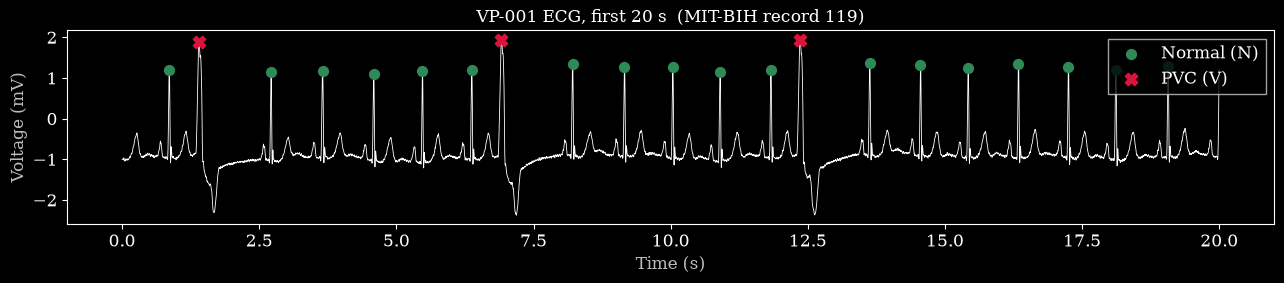

In [5]:
# ── Visualise first 20 s of ECG (provided) ───────────────────────────────────
T_SHOW = 20  # seconds
mask = time < T_SHOW
in_win_N = samples_N[samples_N < T_SHOW * fs_ecg]
in_win_V = samples_V[samples_V < T_SHOW * fs_ecg]

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(time[mask], ecg[mask], linewidth=0.6, color="white")
ax.scatter(
    in_win_N / fs_ecg,
    ecg[in_win_N],
    color="seagreen",
    s=50,
    zorder=3,
    label="Normal (N)",
)
ax.scatter(
    in_win_V / fs_ecg,
    ecg[in_win_V],
    color="crimson",
    s=80,
    marker="X",
    zorder=3,
    label="PVC (V)",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Voltage ({record.units[ECG_CHANNEL]})")
ax.set_title(f"VP-001 ECG, first {T_SHOW} s  (MIT-BIH record {ECG_RECORD})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Task 1.1: Recording duration and PVC burden ──────────────────────────────
# 📋 The previous cell already loaded the data. Now compute and store two values.
#    (a) duration_h  is the total recording length in HOURS
#    (b) pvc_burden  is the PVC fraction as a percentage of all annotated beats
#    The prints below then report the three numbers you need.

# ── 🧠 Your solution — Task 1.1 ────────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
duration_h = TODO
pvc_burden = TODO

# duration_h = ...
# pvc_burden = ...


print(f"Recording duration : {duration_h:.2f} h  ({len(ecg)} samples, fs={fs_ecg} Hz)")
print(f"Normal beats (N)   : {len(idx_N):6d}")
print(f"PVC beats    (V)   : {len(idx_V):6d}  →  burden = {pvc_burden:.2f}%")

### 1.2 Echocardiogram: Left Ventricular Geometry

A 2D echocardiogram produces live B-mode ultrasound images of the heart. The **apical 2-chamber (A2C) view** images the left ventricle (LV) along its long axis.

Two frames matter most in each cycle:

| Frame | Description | LV volume |
|-------|-------------|----------|
| **End-diastole (ED)** | Just before contraction, LV fully filled | Maximum (EDV) |
| **End-systole (ES)** | Peak contraction, blood ejected | Minimum (ESV) |

The **Ejection Fraction (EF)** is the primary clinical measure of LV systolic function. It's defined as:

$$\boxed{\text{EF} = \frac{\text{EDV} - \text{ESV}}{\text{EDV}} \times 100\%}$$

Normal is **≥ 55 %**. A value below 40 % indicates heart failure with reduced ejection fraction (HFrEF).

#### 📋 Task 1.2

Run the cells below to load and play the echocardiogram frames. By visual inspection, which frame looks like ED, and which looks like ES?


In [ ]:
# ── Load CAMUS echocardiogram frames ──────────────────────────────────────────
# The camus-sample dataset has one patient (patient0401) with two views:
#   - patient0401_2CH_half_sequence.hdf5  →  17 frames  (apical 2-chamber, the view we use)
#   - patient0401_4CH_half_sequence.hdf5  →  15 frames  (apical 4-chamber, not used)
# Loading all 17 frames gives the full ED→ES sequence for the 2CH view.
INFERENCE_SIZE = 256
N_FRAMES = 17

with zea.File(
    "hf://zeahub/camus-sample/val/patient0401/patient0401_2CH_half_sequence.hdf5"
) as file:
    echo_frames = file.data.image.values[:]  # (frames × H × W × channels)

echo_frames = zea.func.translate(echo_frames, (-60, 0), (0, 255))

N_FRAMES = echo_frames.shape[0]  # actual frames returned
print(
    f"Echo frames loaded: frames x height x width = {echo_frames.shape} "
    "complete ED→ES sequence for VP-001, 2CH view"
)

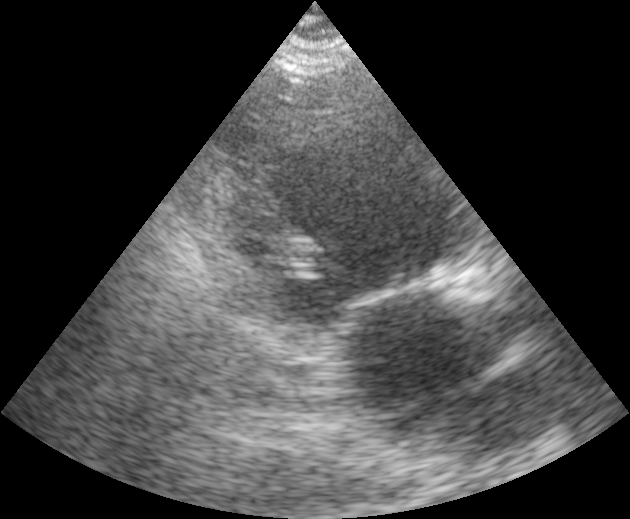

In [8]:
# ── Visualise all echo frames ─────────────────────────────────────────────────
frames = echo_frames.astype(np.uint8)
gif_frames = [Image.fromarray(f) for f in frames]

buf = io.BytesIO()
gif_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=gif_frames[1:],
    duration=120,
    loop=0,
)

display(IPyImage(data=buf.getvalue()))

In [ ]:
# ── Manual frame inspector (slider) ──────────────────────────────────────────

png_frames = []
for f in frames:
    _buf = io.BytesIO()
    Image.fromarray(f).save(_buf, format="PNG")
    png_frames.append(_buf.getvalue())

img_widget = widgets.Image(value=png_frames[0], format="png")
label = widgets.Label(value="Frame 0")
slider = widgets.IntSlider(
    min=0,
    max=len(frames) - 1,
    value=0,
    description="Frame",
    continuous_update=False,
)


def _on_change(change):
    i = change["new"]
    img_widget.value = png_frames[i]
    label.value = f"Frame {i}"


slider.observe(_on_change, names="value")
display(widgets.VBox([slider, label, img_widget]))

##### 🧠 Your solution — Task 1.2

> Write your explanation here.


### 1.3 R-Peak Detection from a Noisy ECG via Matched Filter

In Task 1.1 we took the *annotated* R-peak indices as given. Real recordings are rarely that clean. In practice, detecting the peaks is a signal-processing problem in itself, and a noisy one. So here we take the role of the BMSP unit on day one of VP-001's recording. We add **realistic noise** to the clean ECG (Gaussian noise plus a slow baseline drift), then detect the R-peaks ourselves before any further analysis.

#### Theory: matched filter as the optimal linear detector

Suppose we want to detect a known signal $\mathbf{s}\in\mathbb{R}^N$, the QRS template, buried in additive noise. We design a linear filter with coefficients $\mathbf{h}\in\mathbb{R}^N$ and read its output at the alignment instant. That output is the inner product

$$y \;=\; \mathbf{h}^T \mathbf{s},$$

and the **output SNR**, meaning the signal energy at that instant divided by the filter's noise gain, is proportional to:

$$\mathrm{SNR}\;\propto\;\frac{|\mathbf{h}^T\mathbf{s}|^2}{\|\mathbf{h}\|^2}$$

We want the $\mathbf{h}$ that maximises this ratio.

The **Cauchy-Schwarz inequality** bounds the numerator by the product of the squared norms:

$$|\mathbf{h}^T\mathbf{s}|^2 \;\leq\; \|\mathbf{h}\|^2 \, \|\mathbf{s}\|^2$$

Substitute that back and the $\|\mathbf{h}\|^2$ terms cancel. What remains is an upper bound set by the **signal energy** $\|\mathbf{s}\|^2$. No linear filter can do better. Cauchy-Schwarz also tells us *when* the bound is reached. It holds **only when $\mathbf{h}$ is proportional to $\mathbf{s}$**, so the two vectors are collinear.

To translate "$\mathbf{h} \propto \mathbf{s}$" into a discrete-time filter, recall what convolution computes at the alignment instant. It is the inner product of $\mathbf{s}$ with the **time-reversed** taps. So the optimal filter is the signal reversed in time:

$$\boxed{\;h_{\mathrm{MF}}[n] \;=\; s[N-1-n]\;}$$

Convolving with $h_{\mathrm{MF}}$ is equivalent to **cross-correlating** the input with the template:

$$y[n] \;=\; (h_{\mathrm{MF}} * x)[n] \;=\; \sum_{k=0}^{N-1} s[k]\, x[n - (N-1) + k]$$

A peak in $y[n]$ marks where a real QRS complex aligns with the template. There is a useful consequence here. Under Gaussian noise this matched filter is **equivalent to the maximum-likelihood / Neyman-Pearson detector**, so it carries directly into Part 3.

#### Why this matters for VP-001

The clinic's 30-min Holter is clean. Plain amplitude thresholding would handle it. But VP-001 is monitored at home for the next 48 hours, and that recording will contain movement artefact and drift from poor electrode contact. So we validate the matched-filter pipeline on a synthetically noised copy of the clean clinic recording first. That's the sensible step before trusting it on the home data.


#### 📋 Task 1.3a

Run the cell below. It builds a QRS template from a single Normal beat, adds synthetic noise (Gaussian plus baseline drift), and plots the clean signal against the noisy one. Now look at the plot. What feature of the noisy signal would cause a plain amplitude threshold to fail?


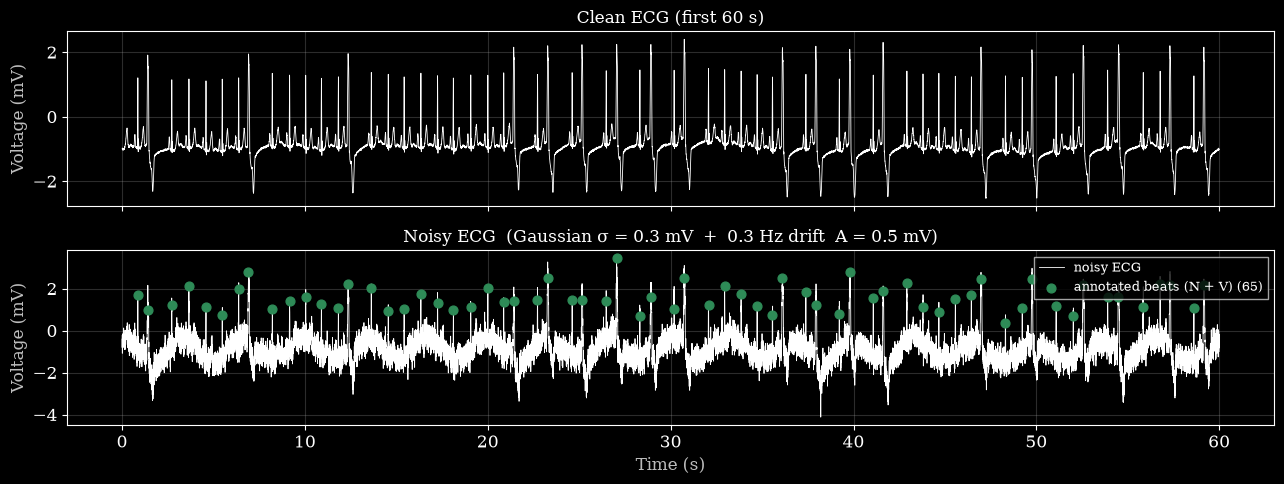

Annotated beats in slice  : 65
QRS template length        : 57 samples (≈ 158 ms wide)


In [10]:
# ── Task 1.3a: Inspect the noisy ECG (provided) ──────────────────────────────
# This cell is fully provided. It builds a QRS template (about 160 ms wide) from
# one Normal beat, adds synthetic noise to the first 60 s of the ECG (Gaussian
# σ = 0.30 mV plus a 0.3 Hz baseline-drift cosine), and plots the clean signal
# next to the noisy one so you can see the kind of artefact a home Holter produces.

# ─── Setup ───────────────────────────────────────────────────────────────────
SLICE_S = 60
slice_n = int(SLICE_S * fs_ecg)
ecg_clean = ecg[:slice_n]
t_slice = np.arange(slice_n) / fs_ecg


# Build QRS template from one Normal beat (~160 ms wide, centred on the R-peak)
def build_qrs_template(sig, beat_idx, fs, half_ms=80):
    half = int(half_ms / 1000 * fs)
    return sig[beat_idx - half : beat_idx + half + 1]


template_idx = int(samples_N[1])
qrs_template = build_qrs_template(ecg, template_idx, fs_ecg)
qrs_template = qrs_template - np.mean(qrs_template)  # zero-mean → robust to DC offsets

# Synthetic noise: Gaussian + low-frequency baseline drift
NOISE_STD = 0.30
DRIFT_AMP = 0.50
ecg_noisy = (
    ecg_clean + rng.normal(0, NOISE_STD, slice_n) + DRIFT_AMP * np.cos(2 * np.pi * 0.3 * t_slice)
)

# Annotated R-peak samples that fall within this slice
# These are all annotated beats (Normal + PVC) in the slice. The matched filter
# detects heartbeats regardless of type. Distinguishing Normal from PVC is a
# separate problem, handled in Part 3 with Neyman-Pearson.
samples_all = np.sort(np.concatenate([samples_N, samples_V]))
ann_in_slice = samples_all[samples_all < slice_n]

# ─── Plot: clean vs noisy ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t_slice, ecg_clean, color="white", linewidth=0.6)
axes[0].set_ylabel("Voltage (mV)")
axes[0].set_title("Clean ECG (first 60 s)")
axes[0].grid(alpha=0.25)

axes[1].plot(t_slice, ecg_noisy, color="white", linewidth=0.6, label="noisy ECG")
axes[1].scatter(
    ann_in_slice / fs_ecg,
    ecg_noisy[ann_in_slice],
    color="seagreen",
    marker="o",
    s=40,
    zorder=3,
    label=f"annotated beats (N + V) ({len(ann_in_slice)})",
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Voltage (mV)")
axes[1].set_title(f"Noisy ECG  (Gaussian σ = {NOISE_STD} mV  +  0.3 Hz drift  A = {DRIFT_AMP} mV)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Annotated beats in slice  : {len(ann_in_slice)}")
print(
    f"QRS template length        : {len(qrs_template)} samples "
    f"(≈ {1000 * len(qrs_template) / fs_ecg:.0f} ms wide)"
)

##### 🧠 Your solution — Task 1.3a

> Write your explanation here.


#### 📋 Task 1.3b

Implement the matched filter by **cross-correlating** the noisy ECG with the QRS template. Threshold the output. Then require at least **250 ms** between one detected peak and the next. The reason is simple. A normal heart rate cannot exceed about 240 bpm, so two real R-peaks are always at least 250 ms apart. That spacing also prevents flagging the same QRS complex twice.

#### 📋 Task 1.3c

Now evaluate it against the annotation. Compute the **true-positive rate (TPR / sensitivity)** and the **false-positive count**, counting a detection as correct when it falls within ±50 ms of an annotated peak. Then discuss where plain threshold detection on the matched-filter output falls short.


In [ ]:
# ── Task 1.3b/c: Implement and evaluate the matched filter ───────────────────
# 📋 (b i) Build the matched-filter output.
#         Subtract the mean of `ecg_noisy` so DC can't skew it. Cross-correlate
#         that with `qrs_template`. Then divide by the peak absolute value so the
#         result lies on [-1, 1].
#         Useful: scipy.signal.correlate().
#
#     (b ii) Detect candidate R-peaks.
#         Threshold the normalised output, and also require at least 250 ms between
#         detections. A normal heart rate cannot exceed about 240 bpm, so two real
#         R-peaks are always at least 250 ms apart. Convert 250 ms to samples with
#         `fs_ecg`.
#         Useful: scipy.signal.find_peaks().
#
#     (c) Evaluate it against `ann_in_slice`. A detection counts as a true positive
#         when it falls within ±50 ms of an annotated R-peak. Report the TPR
#         (sensitivity) and the false-positive count. Then discuss where plain
#         threshold detection starts to struggle.

# ── 🧠 Your solution — Task 1.3b and 1.3c ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 1.3c

> Write your explanation here.


---
## Part 2 · HRV: Distribution Fitting & Spectral Analysis (35 pts)

### 2.1 The R-R Interval Series as a Random Process

The sequence of inter-beat intervals $\{T_k\}$ (R-R intervals, in seconds) is a discrete-time random process. Under normal sinus rhythm it can be modelled as **wide-sense stationary (WSS)**:

$$E[T_k] = \mu_T = \text{const}, \qquad R_{TT}[m] = E[T_k\,T_{k+m}] \text{ depends only on lag } m$$

**Heart rate variability (HRV)** quantifies the beat-to-beat fluctuations. These changes are driven by the autonomic nervous system, which constantly balances its sympathetic branch (which speeds the heart up) against its parasympathetic or vagal branch (which slows it down). Higher variability generally reflects a healthier, more adaptable heart, so a reduced HRV is a recognised marker of cardiac risk. Time-domain metrics:

| Metric | Formula | Clinical interpretation |
|--------|---------|------------------------|
| Mean RR | $\bar{T} = \frac{1}{N}\sum_{k=1}^N T_k$ | Average heart rate |
| SDNN | $\sqrt{\frac{1}{N-1}\sum_k (T_k - \bar{T})^2}$ | Overall HRV, reflects all cyclic components |
| RMSSD | $\sqrt{\frac{1}{N-1}\sum_k (T_{k+1}-T_k)^2}$ | Short-term HRV, parasympathetic tone |

#### 📋 Task 2.1

Compute mean RR, SDNN, and RMSSD for the *Normal beats only* (exclude PVC intervals, which would bias the estimate). Convert mean RR to heart rate in bpm.

In [ ]:
# ── Extract R-R intervals (provided) ─────────────────────────────────────────
# We use every annotated beat here.
rr_all = np.diff(samples) / fs_ecg  # all intervals (s)
rr_symbols = symbols[1:]  # symbol of the beat that ENDS each interval (length N-1)

# Normal-beat intervals only: both bounding beats must be Normal (N→N).
# This excludes N→V (short pre-ectopic interval) and V→N (compensatory pause),
# both of which inflate SDNN and RMSSD when PVC burden is high.
rr_N = rr_all[(symbols[:-1] == "N") & (symbols[1:] == "N")]
rr_V = rr_all[(symbols[:-1] == "V")]  # all intervals ending with PVC (V), i.e. N→V and V→V

print(f"Total R-R intervals  : {len(rr_all):6d}")
print(f"  ↳ N→N (pure sinus) : {len(rr_N):6d}")
print(f"  ↳ ending PVC    (V): {len(rr_V):6d}")

In [ ]:
# ── Task 2.1: HRV time-domain metrics ────────────────────────────────────────
# 📋 Use rr_N (Normal R-R intervals only) for an unbiased HRV estimate.
#    PVC intervals are excluded because they contain a short pre-ectopic interval
#    followed by a long compensatory pause, which inflates SDNN and RMSSD.

# ── 🧠 Your solution — Task 2.1 ────────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      mean_rr  – mean Normal R-R interval (s)
#      hr_bpm   – heart rate (bpm)
#      sdnn     – SDNN, beat-to-beat variability (s)
#      rmssd    – RMSSD, short-term variability (s)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
mean_rr = TODO
hr_bpm = TODO
sdnn = TODO
rmssd = TODO

print(f"Mean RR  : {mean_rr:.3f} s   →   HR = {hr_bpm:.1f} bpm")
print(f"SDNN     : {sdnn * 1000:.1f} ms   (healthy adult rest: 30–100 ms)")
print(f"RMSSD    : {rmssd * 1000:.1f} ms   (healthy adult rest: 20–60 ms)")

### 2.2 Distribution Fitting via Least-Squares (Gauss-Newton)

In Task 2.1 you computed the sample mean and sample standard deviation of $\{T_k\}$. Under a Gaussian assumption, the **sample mean is exactly the MLE** for $\mu$ (Ch 7). The **unbiased sample variance** differs from the MLE variance only by an $N/(N-1)$ correction, which is negligible for $N \gg 1$:

$$\hat\mu_{\mathrm{MLE}} = \frac{1}{N}\sum_{k=1}^{N} T_k, \qquad \hat\sigma^2_{\mathrm{MLE}} = \frac{1}{N}\sum_{k=1}^{N} (T_k - \hat\mu)^2$$

We now approach the same parameter-estimation problem from a **different angle**, least-squares fitting of the histogram (Ch 9). This is conceptually distinct from MLE. Instead of maximising the likelihood of i.i.d. samples, we minimise the squared error between the empirical histogram and the predicted Gaussian PDF.

#### Problem setup

Given the histogram $\{(x_i, y_i)\}_{i=1}^{B}$ where $x_i$ is the bin centre and $y_i$ is the normalised bin count (PDF estimate), we minimise:

$$S(\boldsymbol\theta) = \sum_{i=1}^{B} \big(y_i - p(x_i \mid \boldsymbol\theta)\big)^2, \qquad p(x\mid\boldsymbol\theta) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\quad \boldsymbol\theta = [\mu,\sigma]^T$$

This objective is non-linear in $\boldsymbol\theta$, so we cannot solve it in closed form. We apply the **Gauss-Newton** iteration:

$$\Delta\boldsymbol\theta = (J^T J)^{-1} J^T \boldsymbol\varepsilon,\qquad \boldsymbol\theta_{k+1} = \boldsymbol\theta_k + \alpha\, \Delta\boldsymbol\theta_k$$

where $\boldsymbol\varepsilon = \boldsymbol y - p(\boldsymbol x \mid \boldsymbol\theta)$ and the Jacobian $J\in\mathbb{R}^{B\times 2}$ collects the partial derivatives of $p$ with respect to the parameters.


#### 📋 Task 2.2a

Hand-derive the partial derivatives $\partial p/\partial\mu$ and $\partial p/\partial\sigma$ of the Gaussian PDF. Write out the Jacobian matrix $J$ explicitly.


##### 🧠 Your solution — Task 2.2a

> Write your explanation here.


#### 📋 Task 2.2b

Implement the Gauss-Newton iteration **from scratch** (do not use a built-in optimiser for this part). You may evaluate the Gaussian PDF with `norm.pdf` (already imported). Only the Gauss-Newton update itself must be coded by hand. Use tolerance $10^{-6}$, maximum 100 iterations, learning rate $\alpha = 1.0$, and initialise from $[\mu_0, \sigma_0]$ = sample moments of the data. Track the sum-of-squared errors per iteration and plot it on a `semilogy` axis to visualise convergence. Report your converged $\hat\mu$ and $\hat\sigma$.

In [ ]:
# ── Task 2.2b: Gauss-Newton LSE fit (from scratch) ──────────────────────
# 📋 Build a histogram of rr_N (~30 bins, density=True), then implement
#    Gauss-Newton from scratch (Jacobian from Task 2.2a). Track the SSE per
#    iteration, plot it on a semilogy axis, and report the converged mu, sigma.
#    Useful: np.histogram, np.linalg.solve.

# ── 🧠 Your solution — Task 2.2b ────────────────────────────────────────────────
# ... your code here ...



#### 📋 Task 2.2c

Run `scipy.optimize.curve_fit` on the same histogram and compare. Then compare both LSE estimates against the MLE estimates from Task 2.1. Are they identical? Explain why or why not in 1–2 sentences. *Hint: think about what each method optimises, the likelihood of samples versus the squared error on bin counts.*

In [ ]:
# ── Task 2.2c: Compare LSE (curve_fit) against MLE ──────────────────────
# 📋 Fit the same histogram (x, y) with scipy.optimize.curve_fit and compare
#    to your Gauss-Newton result. Also compare both LSE fits to the MLE from 2.1.
#    Explain any difference in the markdown solution cell below.

# ── 🧠 Your solution — Task 2.2c ────────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
x_plot = TODO



##### 🧠 Your solution — Task 2.2c

> Write your explanation here.


### 2.3 HRV Spectral Analysis: Estimator Choice & Uncertainty

**Research question.** *Estimate the LF/HF power ratio of VP-001's R-R interval series, and report it together with a quantified uncertainty.* The estimator framework you choose, the windowing decisions you make, and the assumptions you accept or reject are part of your answer.

#### Background

The PSD of the R-R series decomposes HRV into three frequency bands:

| Band | Range | Source |
|------|-------|--------|
| VLF | 0.003–0.04 Hz | thermoregulation, renin-angiotensin |
| **LF** | **0.04–0.15 Hz** | sympathetic + parasympathetic (baroreflex) |
| **HF** | **0.15–0.40 Hz** | parasympathetic / respiratory sinus arrhythmia |

Because the sympathetic and parasympathetic branches act on different time scales, they appear in different frequency bands. The **LF/HF ratio** is therefore read as a rough index of sympathovagal balance, where a higher ratio points to sympathetic (stress) dominance and a lower ratio points to parasympathetic (rest) dominance.

The R-R sequence is non-uniformly sampled. A uniform 4 Hz resampling step is provided in the cell below.

#### Methods that you can use

 The course has given you several estimators. Pick from the list of methods below and justify your choices.

| Choice | Options | Course chapter |
|---|---|---|
| Window | rectangular, Hann, Hamming, Blackman, … | Ch 11 |
| Non-parametric estimator | periodogram, Bartlett, Welch (WOSA), Blackman-Tukey | Ch 12 |
| Parametric model | AR via Yule-Walker | Ch 13 |


In [ ]:
# ── Resampling to uniform grid (provided) ────────────────────────────────────
# We restrict the HRV analysis to the first 15 minutes of the recording,
# where the R-R series is approximately stationary (verify in Task 2.3a).
# The full 30-minute record is still used in Part 3 for arrhythmia detection.
# The time axis below uses real wall-clock beat times. This is necessary because
# the N→N filter excludes intervals around PVCs, leaving real gaps in the series.

fs_rr = 4.0
PART2_DURATION_S = 15 * 60

mask_NN = (symbols[:-1] == "N") & (symbols[1:] == "N")
end_time = samples[1:] / fs_ecg  # wall-clock time of each interval's end
mask_win = end_time < PART2_DURATION_S
mask = mask_NN & mask_win

rr_N_p2 = rr_all[mask]
t_rr = end_time[mask]  # real wall-clock time axis (s)
t_uniform = np.arange(t_rr[0], t_rr[-1], 1.0 / fs_rr)
rr_resampled = np.interp(t_uniform, t_rr, rr_N_p2)

print(f"HRV window           : first {PART2_DURATION_S} s of the recording")
print(f"N→N intervals used   : {len(rr_N_p2)}")
print(
    f"Resampled R-R series : {len(rr_resampled)} samples at {fs_rr} Hz "
    f"(window duration ≈ {len(rr_resampled) / fs_rr:.0f} s)"
)

#### 📋 Task 2.3a — Validate the WSS assumption

Task 2.1 modelled $\{T_k\}$ as wide-sense stationary. The PSD framework requires this. Empirically test it on this record: state your test, your result, and the consequences for what follows.


In [ ]:
# ── Task 2.3a: Test the WSS assumption ───────────────────────────────────────
# 📋The PSD framework requires the R-R series to be WSS. Test it.
#    Recall the WSS conditions: (i) constant mean, (ii) constant variance,
#    (iii) autocorrelation depending only on lag.
#
#    You decide *how* to test.  Choose an approach you can
#    justify. State your conclusion in the markdown cell below.

#    Might be useful: np.array_split, scipy.ndimage.uniform_filter1d (sliding-window
#    moments without boundary artefacts), np.correlate (autocorrelation per segment).

# ── 🧠 Your solution — Task 2.3a ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3a

> Write your explanation here.


#### 📋 Task 2.3b — Pick non-parametric estimators

Implement at least **two** estimators from the methods in Ch 12. Plot them on the same axes. Justify your final choice for this record in terms of the bias–variance tradeoff and the role of windowing in spectral leakage across the LF/HF boundary at 0.15 Hz. Compute and report the resulting LF/HF.


In [ ]:
# ── Task 2.3b: Non-parametric estimator comparison ───────────────────────────
# 📋 Implement *at least two* of: periodogram, Bartlett, Welch, Blackman-Tukey.
#    Plot on the same axes. Discuss bias–variance and leakage at 0.15 Hz.
#
#    Useful: scipy.signal.welch, scipy.signal.periodogram, scipy.signal.windows, np.trapezoid (for band-power integration).
#
#    Compute LF/HF from your chosen estimate via trapezoidal integration:
#        mask = (freqs >= f_low) & (freqs <= f_high)
#        band_power = np.trapezoid(psd[mask], freqs[mask])

# ── 🧠 Your solution — Task 2.3b ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3b

> Write your explanation here.


#### 📋 Task 2.3c — Fit a parametric AR model

Fit AR via Yule-Walker. Sweep over a range of orders and select $p^*$ by minimising the AIC. Justify the order range you sweep. Compute and report the AR-based LF/HF.


In [ ]:
# ── Task 2.3c: AR fit + AIC order selection ──────────────────────────────────
# 📋 Fit AR(p) via yule_walker over a sweep of orders. Select p* by minimising
#    the Akaike Information Criterion (Ch 13):
#        AIC(p) = N · ln(σ²(p)) + 2p
#    where σ²(p) is the residual noise variance returned by yule_walker.
#    Justify the order range you sweep.
#
#    Then evaluate the AR PSD and compute LF/HF:
#        P(f) = (σ² / |1 − Σ_k ρ_k · exp(−2πjfk/fs)|²) · (2/fs)

#    Useful: yule_walker (already imported). scipy.signal.freqz is a convenient
#    alternative way to evaluate the AR PSD via the filter denominator.

# ── 🧠 Your solution — Task 2.3c ───────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
best_idx = TODO




##### 🧠 Your solution — Task 2.3c

> Write your explanation here.


#### 📋 Task 2.3d — Reconcile the parametric and non-parametric estimates

(a) Overlay the Welch PSD (generate it, if you did not use it in Task 2.3b) and the AR PSD (from 2.3c) on a single semilog plot, with the LF and HF bands shaded. (b) Print a side-by-side numerical comparison of the LF/HF values produced by each method, including the absolute and relative gap. (c) Discuss in 3-4 sentences. Where do the two PSDs agree visually? Where do they differ, and *why*? Think about each method's underlying assumption (parametric AR model versus averaged periodogram). Which method's character would you trust more for this patient's recording, and what is the trade-off?


In [ ]:
# ── Task 2.3d: Reconcile parametric and non-parametric estimators ────────────
# 📋 (a) Overlay the Welch PSD (f_w, P_w from 2.3b) and the AR PSD (f_ar, P_ar
#        from 2.3c) on a single semilog plot. Shade the LF (0.04–0.15 Hz) and
#        HF (0.15–0.40 Hz) bands.
#    (b) Print a side-by-side comparison of the LF/HF values from each method
#        (lf_hf_np from 2.3b, lf_hf_ar from 2.3c) including the absolute gap
#        |Δ| and the relative gap |Δ| / max(LF/HF) in percent.
#    (c) Use the markdown discussion below to comment on agreement / differences
#        and which method you would trust on this record.

# ── 🧠 Your solution — Task 2.3d ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3d

> Write your explanation here.


#### 📋 Task 2.3e — Reflect on stationarity

Reflect back on your WSS finding in Task 2.3a. What are the consequences of this finding for the PSD framework and the estimates you obtained in Tasks 2.3b–2.3d?


##### 🧠 Your solution — Task 2.3e

> Write your explanation here.


### 2.4 Time-Frequency Analysis: LF/HF Trajectory

Section 2.3 produced a single LF/HF estimate for the first 15 minutes of the recording, the stretch where the WSS assumption holds. The cardiologist will also want to see whether the autonomic state is **stable across the entire 30-minute Holter** or whether episodes of imbalance appear.

This section shifts from a global PSD to a **time-resolved** view. Instead of one LF/HF for the whole record, we compute LF/HF on sliding windows and plot the trajectory $\widehat{\text{LF/HF}}(t)$. This is the natural diagnostic complement to Task 2.3a. When stationarity fails, the time-resolved trajectory is the right way to present the result.

#### 📋 Task 2.4

Resample the **full 30-minute** R-R series (using the same real-wall-clock-time construction from Task 2.3, but without the 15-minute restriction). Apply a sliding-window Welch estimator with a 5-minute window and 60 % overlap. For each window, compute the LF and HF band powers and the LF/HF ratio. Plot:
1. LF and HF band powers vs. time (top axis),
2. LF/HF ratio vs. time with the clinical threshold ($\text{LF/HF} = 2$) marked (bottom axis).

Discuss in 2-3 sentences what the trajectory reveals about the patient's autonomic state across the recording, and how this connects to your stationarity finding in Task 2.3a.


In [ ]:
# ── Task 2.4: Time-frequency LF/HF trajectory ────────────────────────────────
# 📋 (1) Resample the FULL 30-minute R-R series (no 15-minute restriction).
#    (2) Sliding-window Welch with a 5-min window and 60% overlap. For each
#        window, integrate over LF (0.04–0.15 Hz) and HF (0.15–0.40 Hz) bands.
#    (3) Plot LF and HF powers (top), LF/HF ratio (bottom). Mark LF/HF=2.

# ── 🧠 Your solution — Task 2.4 ────────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.4

> Write your explanation here.


---
## Part 3 · Arrhythmia Detection: Multi-Feature Neyman-Pearson (25 pts)

This part builds a PVC detector in four steps. Sub-tasks 3.2–3.4 all place a decision threshold on the **same** feature you design in 3.1. They differ only in *how* the threshold is chosen, so read them as four answers to four distinct questions:

| Sub-task | Question it answers | What you hand in |
|----------|---------------------|------------------|
| **3.1: Feature design** | Which scalar feature best separates Normal vs PVC beats? | code **+ written justification** |
| **3.2: Neyman–Pearson detector** | At a fixed 10 % false-alarm rate, what detection rate results, and how strong is the detector overall (ROC, AUC)? | code (report the printed numbers) |
| **3.3: Youden operating point** | Without fixing $P_{FA}$, which threshold best balances sensitivity and specificity? | code (report the printed numbers) |
| **3.4: Bayesian decision rules** | How do class priors and misclassification costs shift the threshold, and which rule do you ship? | code **+ written justification** |

### 3.1 Feature Design

We formulate PVC detection as a **binary hypothesis test** on a scalar feature $x_k$ extracted from the R-R sequence around beat $k$:

$$H_0:\; x \sim \mathcal{N}(\mu_0, \sigma_0^2) \quad \text{(Normal beat)}, \qquad H_1:\; x \sim \mathcal{N}(\mu_1, \sigma_1^2) \quad \text{(PVC beat)}$$

The **quality of your detector depends entirely on how well your feature separates the two classes.** A good feature exploits the characteristic electrophysiological signature of PVCs in the R-R sequence:

| Event | Effect on surrounding R-R intervals |
|-------|-------------------------------------|
| PVC beat itself | Arrives *early* → abnormally short pre-ectopic interval |
| Beat immediately after PVC | Arrives *late* (compensatory pause) → abnormally long post-ectopic interval |
| Sinus beats far from a PVC | Regular interval, approximately constant |

Your task is to design a scalar feature that **aggregates information from a window of $W$ consecutive R-R intervals** ending at beat $k$, such that it takes consistently different values under $H_0$ and $H_1$.

> 📌 **Think about:** Which statistical summary of the window best captures the PVC signature? Mean, variance, the ratio of consecutive intervals? And how wide should the window $W$ be? Too narrow misses the full pattern, too wide dilutes it. One more thing. A Normal beat adjacent to a PVC inherits distorted intervals (the short pre-ectopic or the long compensatory pause). If you include those intervals in your $H_0$ class, what happens to $\sigma_0$ and your AUC?


The **AUC** has the closed-form expression:

$$\text{AUC} = \Phi\!\left(\frac{|\mu_0 - \mu_1|}{\sqrt{\sigma_0^2 + \sigma_1^2}}\right)$$

A higher AUC means better class separation. In other words, a better feature design.

#### 📋 Task 3.1

Design **at least three** candidate scalar features from the R-R sequence. For each, fit Gaussian distributions to the H0 and H1 classes and compute the analytic AUC = Φ(|μ_0 − μ_1| / √(σ_0² + σ_1²)). Pick the **highest-AUC** feature as your canonical detector input, and assign its values to `feat_N` and `feat_V` for use in 3.2–3.4. Present all candidates in a comparison table and justify both your feature pool and your final selection. Each of the three required features must be genuinely different from the others, capturing a distinct aspect of the PVC signature rather than a near-duplicate of another feature. *Aim for AUC ≥ 0.90 with your best feature.*

> ⚙️ Work from `rr_all` (the **original** beat-to-beat intervals, **whole** recording) with labels `rr_symbols`. Do **not** use the resampled `rr_resampled` from Part 2.

> 🎁 **Bonus: go beyond the three required features (+2.5 each, up to +5).** Each *additional* distinct feature beyond the mandatory three earns **+2.5 bonus points**, for up to **2 extra features** (a maximum of **+5**, i.e. five features in total). Each bonus feature must be genuinely different. It should capture a *different* aspect of the PVC signature, and it must be analysed the same way (its own per-class Gaussian fit and AUC).


In [ ]:
# ── Task 3.1: Multi-feature design + per-feature AUC ─────────────────────────
# 📋 Design at least THREE candidate features over a sliding window of W
#    consecutive R-R intervals ending at beat k. The three required features must each capture a different aspect of the PVC signature (not near-duplicates). Each EXTRA feature beyond three
#    is worth +2.5 bonus (up to 2 extra → +5 max). For each feature:
#       (1) build  feat_N (H0)  and  feat_V (H1) class-conditional samples
#       (2) fit a Gaussian per class                       (μ̂, σ̂  by sample moments)
#       (3) compute the closed-form AUC = Φ(|μ_0 − μ_1| / √(σ_0² + σ_1²))
#    Then assign the *best-AUC* feature's arrays to feat_N, feat_V (these are
#    consumed by the NP detector in Task 3.2 and Youden's J in Task 3.3).
#    Use rr_all + rr_symbols (original intervals, whole recording), not rr_resampled.

# ── 🧠 Your solution — Task 3.1 ────────────────────────────────────────────────
#    Required outputs (consumed by the provided code in Tasks 3.2–3.4):
#      feat_N, feat_V    – chosen-feature samples for H0 / H1 (arrays)
#      mu_H0, sigma_H0   – Gaussian fit of feat_N (mean, std)
#      mu_H1, sigma_H1   – Gaussian fit of feat_V (mean, std)
#      x_plot            – feature-range grid for the PDF overlays
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
feat_N = TODO
feat_V = TODO
mu_H0 = TODO
sigma_H0 = TODO
mu_H1 = TODO
sigma_H1 = TODO
x_plot = TODO




In [ ]:
# ── Task 3.1 (cont.): Visualise the candidate features ───────────────────────
# 📋 Side-by-side histograms + Gaussian fits for every candidate feature.
#    The feature with the cleanest visual separation should also have the
#    highest AUC. This is a sanity check on the table above.

# ── 🧠 Your solution — Task 3.1 (cont.) ─────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 3.1

> Write your explanation here.


### 3.2 Neyman-Pearson Detector

The **Neyman-Pearson (NP) lemma** gives the most powerful test at false-alarm level $\alpha$. For Gaussian distributions the Log-Likelihood Ratio Test (Log-LRT) reduces to a threshold test. Assuming the feature is lower under $H_1$ (declare $H_1$ when $x < \gamma$):

$$P_{FA} = P(x < \gamma \mid H_0) = \Phi\!\left(\frac{\gamma - \mu_0}{\sigma_0}\right) = \alpha \quad\Longrightarrow\quad \boxed{\gamma_{\text{NP}} = \mu_0 + \sigma_0\,\Phi^{-1}(\alpha)}$$

#### 📋 Task 3.2

Evaluate the detector by building its **Receiver Operating Characteristic (ROC)** curve. Sweep a decision threshold across the full range of your selected feature and, at each threshold, measure two rates *empirically* from the class samples: the **false-alarm rate** $P_{FA}$ (fraction of Normal / $H_0$ beats wrongly flagged as PVC) and the **detection rate** $P_D$ (fraction of PVC / $H_1$ beats correctly flagged). Recall that $H_1$ is declared when the feature falls **below** the threshold. The provided code then computes the closed-form Neyman-Pearson threshold for the target $P_{FA} = 0.10$, marks that operating point on the ROC, and reports the empirical area under your ROC alongside the analytic Gaussian AUC. Confirm that the two AUC values agree.


In [ ]:
# ── Task 3.2: ROC curve and NP threshold ──────────────────────────────────────
# 📋 Build the empirical ROC for the detector. Sweep a decision threshold γ
#    across the full range of the selected feature. Declare H1 (PVC) on the side
#    of γ where your feature places PVCs. Use feat < γ if PVCs take the LOWER
#    value, or feat > γ if they take the HIGHER value (check your 3.1 histograms).
#    At each γ, estimate two rates directly from the class samples and store:
#        thresholds  : the swept γ grid (cover the full feature range)
#        pfa_curve   : empirical false-alarm rate P_FA under H0 (from feat_N)
#        pd_curve    : empirical detection rate   P_D  under H1 (from feat_V)
#    The provided code below consumes these three arrays to locate the analytic
#    NP threshold at P_FA = 0.10, plot the ROC, and compare empirical vs
#    analytic AUC.

TARGET_PFA = 0.10

# ── 🧠 Your solution — Task 3.2 ────────────────────────────────────────────────
#    Required outputs (used by the provided ROC/AUC code and by Task 3.3):
#      thresholds – swept decision-threshold grid
#      pfa_curve  – empirical P_FA at each threshold
#      pd_curve   – empirical P_D  at each threshold
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
thresholds = TODO
pfa_curve = TODO
pd_curve = TODO

if answered(
    thresholds, pfa_curve, pd_curve, feat_N, feat_V, mu_H0, sigma_H0, mu_H1, sigma_H1, x_plot
):
    # Closed-form NP threshold and detection prob, works for either feature direction
    pvc_low = mu_H1 < mu_H0
    gamma_np = mu_H0 + sigma_H0 * norm.ppf(TARGET_PFA if pvc_low else 1 - TARGET_PFA)
    pd_at_target = (
        norm.cdf(gamma_np, mu_H1, sigma_H1) if pvc_low else norm.sf(gamma_np, mu_H1, sigma_H1)
    )

    # AUC: empirical (trapezoidal rule) and analytic (Gaussian closed form)
    sort_idx = np.argsort(pfa_curve)
    auc_empirical = np.trapezoid(pd_curve[sort_idx], pfa_curve[sort_idx])
    auc_analytic = norm.cdf(abs(mu_H0 - mu_H1) / np.sqrt(sigma_H0**2 + sigma_H1**2))

    print(f"Empirical AUC     : {auc_empirical:.4f}")
    print(f"Analytic AUC      : {auc_analytic:.4f}")
    print(
        f"NP threshold γ    : {gamma_np:.3f} s   (P_FA = {TARGET_PFA:.2f}, P_D = {pd_at_target:.3f})"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve
    axes[0].plot(pfa_curve[sort_idx], pd_curve[sort_idx], "b-", linewidth=2, label="Empirical ROC")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
    axes[0].plot(
        TARGET_PFA,
        pd_at_target,
        "ro",
        markersize=10,
        label=f"NP point: $P_{{FA}}$={TARGET_PFA:.2f}, $P_D$={pd_at_target:.3f}",
    )
    axes[0].set_xlabel("$P_{FA}$  (False Alarm Rate)")
    axes[0].set_ylabel("$P_D$  (Detection Rate)")
    axes[0].set_title(f"ROC Curve  (AUC = {auc_empirical:.4f})")
    axes[0].legend()
    axes[0].set_aspect("equal")

    # Feature distributions + NP threshold
    axes[1].hist(feat_N, bins=50, density=True, alpha=0.4, color="seagreen", label="$H_0$ Normal")
    axes[1].hist(feat_V, bins=20, density=True, alpha=0.4, color="crimson", label="$H_1$ PVC")
    axes[1].plot(x_plot, norm.pdf(x_plot, mu_H0, sigma_H0), "g-", linewidth=2)
    axes[1].plot(x_plot, norm.pdf(x_plot, mu_H1, sigma_H1), "r-", linewidth=2)
    axes[1].axvline(
        gamma_np,
        color="k",
        linestyle="--",
        linewidth=2,
        label=f"NP threshold γ = {gamma_np:.3f} s",
    )
    axes[1].set_xlabel("Mean R-R feature (s)")
    axes[1].set_title(f"NP Threshold Visualisation  ($P_{{FA}}$ = {TARGET_PFA})")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Task 3.2 (or a prerequisite in Task 3.1) is unanswered, skipping the ROC/AUC figure.")

### 3.3 Operating Point Selection: Youden's J

The Neyman–Pearson point in Task 3.2 *fixes* the false-alarm rate at a chosen level. A different, equally common choice is the threshold that maximises **Youden's J** statistic, $J = P_D - P_{FA}$, the vertical gap between the ROC curve and the chance diagonal. This is the operating point with the best *simultaneous* sensitivity and specificity, appropriate when a false alarm and a missed detection are treated as equally costly.

#### 📋 Task 3.3

Using the ROC sweep (`thresholds`, `pfa_curve`, `pd_curve`) from Task 3.2, find the threshold that maximises Youden's J. Report the optimal threshold together with its $P_D$ and $P_{FA}$, and note from the output how this operating point compares with the NP point from Task 3.2. Does dropping the fixed-$P_{FA}$ constraint buy a higher detection rate?


In [ ]:
# ── Task 3.3: Optimal threshold via Youden's J statistic ─────────────────────
# 📋 Youden's J = P_D − P_FA is the vertical distance from the ROC curve to
#    the diagonal chance line. Maximising J yields the threshold that gives
#    the best simultaneous sensitivity and specificity. It is the operating
#    point a clinician would choose if false alarms and missed detections are
#    equally costly.

# ── 🧠 Your solution — Task 3.3 ────────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      J_statistic – Youden's J = P_D − P_FA at each threshold (array)
#      best_idx    – index of the maximum-J threshold
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
J_statistic = TODO
best_idx = TODO

if answered(J_statistic, best_idx, thresholds, pd_curve, pfa_curve):
    gamma_youden = thresholds[best_idx]
    pd_youden = pd_curve[best_idx]
    pfa_youden = pfa_curve[best_idx]

    print(f"Maximum Youden's J*  = {J_statistic[best_idx]:.3f}")
    print(f"Optimal threshold γ* = {gamma_youden:.3f} s")
    print(f"  P_D  (sensitivity) = {pd_youden:.3f}   ({pd_youden * 100:.1f}%)")
    print(f"  P_FA (1-specificity)= {pfa_youden:.3f}   ({pfa_youden * 100:.1f}%)")
    print(
        f"\n  Youden vs. NP:  J*(Youden) = {J_statistic[best_idx]:.3f}  "
        f"vs  J(NP) = {pd_at_target - TARGET_PFA:.3f}"
    )
else:
    print("⚠️  Task 3.3 (or a prerequisite) is unanswered, skipping the Youden-threshold report.")

### 3.4 Bayesian Decision Rules (Ch 10)

Neyman-Pearson fixes a constraint on $P_{FA}$ and maximises $P_D$ subject to it. The **Bayesian framework** takes a different starting point. It minimises the weighted average of both error types, the **Bayes risk**:

$$R(\gamma) \;=\; P(H_0)\,C_{FP}\,P_{FA}(\gamma) \;+\; P(H_1)\,C_{FN}\,P_M(\gamma)$$

where $C_{FP}$ is the cost of a false alarm, $C_{FN}$ the cost of a missed PVC, $P_M(\gamma) = 1 - P_D(\gamma)$ the miss rate, and the priors $P(H_0), P(H_1)$ encode the class proportions you expect *a priori* (here, the empirical PVC burden of the recording). The optimal threshold

$$\gamma_{\text{Bayes}}^* \;=\; \arg\min_\gamma R(\gamma)$$

minimises this risk. With equal costs $C_{FP} = C_{FN}$ this reduces to the **MAP detector**. With asymmetric costs (e.g. clinical screening, where missing a PVC is worse than a false alarm) the threshold shifts to favour sensitivity at the price of more false alarms. That is exactly the trade-off Ch 10 is designed to express.

#### 📋 Task 3.4

Using your canonical feature from Task 3.1, design the following three decision rules from the methods of Ch 10 and Ch 14:
1. **Neyman-Pearson** at $P_{FA} = 0.10$ (reuse $\gamma_{\text{NP}}$ from Task 3.2)
2. **MAP detector**, a Bayes-risk minimiser with equal costs $C_{FP} = C_{FN}$, priors $\hat P(H_0), \hat P(H_1)$ estimated empirically from the data
3. **Bayes-risk minimiser** with an *asymmetric* cost matrix you justify on clinical grounds (e.g. $C_{FN} = 5\,C_{FP}$ for a sensitivity-prioritising screening tool)

For each rule, compute $P_D$, $P_{FA}$, and a summary score you choose. Balanced accuracy $= \tfrac{1}{2}(P_D + 1 - P_{FA})$ is one option, but not the only sensible one. A screening tool might instead rank the rules by sensitivity (recall), by specificity, by Youden's J, or by their cost-weighted Bayes risk. Pick the metric you select on, justify that choice on clinical grounds, and promote the winning rule to a canonical `predict_pvc(feat)` function.

Then comment on what you find, with emphasis on the clinical implications. Do the three rules give different operating points on this feature, and why or why not? Which frame would you deploy for VP-001, Neyman-Pearson's fixed false-alarm budget or a Bayesian weighted-risk rule, and what does that choice express clinically?


In [ ]:
# ── Task 3.4: Bayesian decision-rule design ──────────────────────────────────
# 📋 Using your canonical feature from Task 3.1, design ≥3 decision rules:
#       (1) Neyman-Pearson at TARGET_PFA          → reuse gamma_np from Task 3.2
#       (2) MAP detector                          → Bayes-risk minimiser, C_FN=C_FP=1
#       (3) Bayes-risk minimiser with an asymmetric cost matrix
#           (e.g. C_FN = 5·C_FP for a clinical screening tool)
#
#    For each rule report P_D, P_FA, and a summary score. Balanced accuracy
#    BalAcc = ½ (P_D + 1 − P_FA) is one option. A screening tool might instead
#    weight sensitivity or cost-weighted risk. Select a rule under the metric
#    you justify and promote it to predict_pvc(feat).

# ── 🧠 Your solution — Task 3.4 ────────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 3.4

> Write your explanation here.


---
## Part 4 · Left Ventricular Ejection Fraction (30 pts)

### 4.1 Automatic LV Segmentation

We use the pre-trained **AugmentedCamusSeg** model, a deep neural network based on the U-Net architecture trained on the augmented CAMUS dataset, to automatically delineate the LV in each frame:

| Label | Region | Colour |
|-------|--------|--------|
| 0 | Background | none |
| 1 | LV cavity | Red |
| 2 | Myocardium | Blue |

Once the LV mask is available for each frame, we identify **end-diastole (ED)** as the frame with the *largest* LV cavity area, and **end-systole (ES)** as the frame with the *smallest* LV cavity area.

#### 📋 Task 4.1

The provided cell below runs the segmentation model and stores the per-pixel class labels in `masks`, an array of shape $(N_{\text{frames}}, H, W)$. Your job is to turn those labels into clinical indices:

1. **Compute the LV cavity area per frame.** For each frame, count the pixels labelled as LV cavity (`label == 1`) and store the result in `lv_areas`, a length-$N_{\text{frames}}$ integer array, in px².
2. **Identify ED and ES.** `ed_idx` is the frame index with the *largest* `lv_areas`. `es_idx` is the frame index with the *smallest*.
3. **Report.** Print `ed_idx`, `es_idx`, and the full per-frame area table with the ED and ES rows flagged. The plotting code below the answer block will then overlay the segmentation on those two frames.

In [ ]:
# ── Run LV segmentation model (provided) ─────────────────────────────────────
print("Loading AugmentedCamusSeg model...")
model_lv = AugmentedCamusSeg.from_preset("augmented_camus_seg")
print("Model loaded.")

# ONNX model expects NCHW format: (batch, channels, height, width)
echo_batch = echo_frames[..., None]  # (N, H, W, 1)
echo_batch = keras.ops.convert_to_tensor(echo_batch, dtype=np.float32)
# Model expects 256×256 input normalized to [-1, 1]
echo_batch = keras.ops.image.resize(echo_batch, (256, 256))
echo_batch = (echo_batch / 127.5) - 1.0
echo_nchw = keras.ops.transpose(echo_batch, (0, 3, 1, 2))  # (N, 1, 256, 256)
seg_output = model_lv.call(echo_nchw)  # (N, 3, 256, 256), 3-class logits

# Upsample the per-class output back to the original echo resolution so the
# segmentation overlay aligns with the ultrasound frame.
H, W = echo_frames.shape[1], echo_frames.shape[2]
seg_hwc = keras.ops.transpose(seg_output, (0, 2, 3, 1))  # (N, 256, 256, 3)
seg_full = keras.ops.image.resize(seg_hwc, (H, W), interpolation="bilinear")
masks = np.argmax(keras.ops.convert_to_numpy(seg_full), axis=-1)  # (N, H, W)

print(f"\nSegmentation masks shape : {masks.shape}")
print("Pixel labels             : 0 = background, 1 = LV cavity, 2 = myocardium")

Random frame drawn for illustration: 14


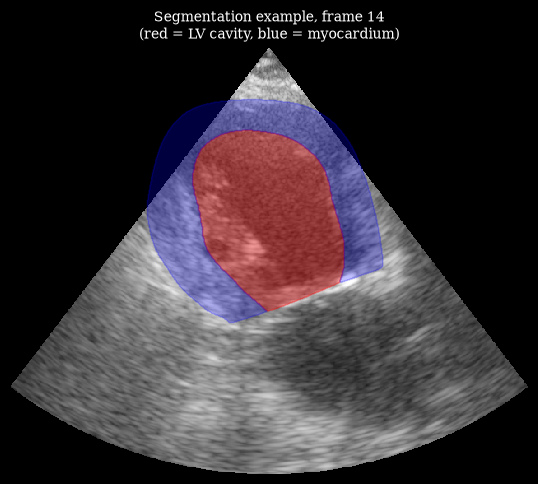

In [28]:
# ── Example: segmentation on one random frame (provided) ─────────────────────
# Pick an arbitrary frame to illustrate what the segmentation model produces.
# The draw is intentionally random. Identifying ED/ES is your job in Task 4.1.
example_idx = int(np.random.default_rng(0).integers(0, N_FRAMES))
print(f"Random frame drawn for illustration: {example_idx}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(echo_frames[example_idx], cmap="gray", vmin=0, vmax=255)
plot_shape_from_mask(ax, masks[example_idx] == 1, color="red", alpha=0.35)
plot_shape_from_mask(ax, masks[example_idx] == 2, color="blue", alpha=0.25)
ax.set_title(
    f"Segmentation example, frame {example_idx}\n(red = LV cavity, blue = myocardium)", fontsize=10
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── Task 4.1: LV areas and ED/ES identification ──────────────────────────────
# Useful: np.sum() on a boolean mask, np.argmax(), np.argmin().

# ── 🧠 Your solution — Task 4.1 ────────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
lv_areas = TODO
ed_idx = TODO
es_idx = TODO

if answered(lv_areas, ed_idx, es_idx):
    print(f"ED frame: {ed_idx}  (A_ED = {lv_areas[ed_idx]} px²)")
    print(f"ES frame: {es_idx}  (A_ES = {lv_areas[es_idx]} px²)")

    print("\nLV cavity area per frame:")
    for i, a in enumerate(lv_areas):
        tag = ""
        if i == ed_idx:
            tag = "  ← ED (max)"
        if i == es_idx:
            tag = "  ← ES (min)"
        print(f"  Frame {i:2d}: {a:6d} px{tag}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, idx, label in zip(axes, [ed_idx, es_idx], ["End-Diastole (ED)", "End-Systole (ES)"]):
        ax.imshow(echo_frames[idx, :, :], cmap="gray", vmin=0, vmax=255)
        plot_shape_from_mask(ax, masks[idx] == 1, color="red", alpha=0.35)
        plot_shape_from_mask(ax, masks[idx] == 2, color="blue", alpha=0.25)
        ax.set_title(f"{label}\nLV area = {lv_areas[idx]} px²", fontsize=11)
        ax.axis("off")
    plt.suptitle("VP-001 LV Segmentation  (red = LV cavity, blue = myocardium)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Task 4.1 is unanswered, skipping the ED/ES summary and figure.")

### 4.2 Calculating the Ejection Fraction

#### Method A: Fractional Area Change (FAC)

For a single apical view, EF can be approximated directly from pixel areas:

$$\text{FAC} = \frac{A_{\text{ED}} - A_{\text{ES}}}{A_{\text{ED}}} \times 100\%$$

This is dimensionless (pixel size cancels), so no calibration is required. Note that FAC is a **2D metric**: it captures how much the cross-sectional area decreases, but not how much the LV shortens along its long axis. The clinically defined EF is a 3D volume ratio. FAC approximates it, but the two are not equivalent.

#### Method B: Simpson's single-plane formula

The more clinically accepted approach approximates the LV as a prolate ellipsoid. For a single-plane view:

$$V = \frac{8\,A^2}{3\pi\,L}$$

where $A$ = LV cavity area (px²) and $L$ = LV long-axis length (px), measured from the apex to the mitral valve plane. Then:

$$\text{EF}_{\text{Simpson}} = \frac{V_{\text{ED}} - V_{\text{ES}}}{V_{\text{ED}}} \times 100\%$$

Because $V \propto A^2/L$, Simpson's method accounts for longitudinal shortening that FAC ignores.


#### 📋 Task 4.2a

Compute the area-method FAC (`EF_area`) directly from $A_{\text{ED}}$ and $A_{\text{ES}}$.


In [ ]:
A_ed = float(lv_areas[ed_idx])
A_es = float(lv_areas[es_idx])
print(f"A_ED = {A_ed:.0f} px²    A_ES = {A_es:.0f} px²")

# ── Task 4.2a: FAC ────────────────────────────────────────────────────────────
# ── 🧠 Your solution — Task 4.2a ───────────────────────────────────────────────
#    Required output (used by the printout below and Tasks 4.2c / 4.3):
#      EF_area – area-method (FAC) ejection fraction (%)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
EF_area = TODO

print(f"FAC (2D area method): {EF_area:.1f}%")

#### 📋 Task 4.2b

**Implement** the `lv_long_axis_length()` helper in the cell below. Given a single binary LV-cavity mask `mask_lv` (one frame, shape `(H, W)`), extract the (row, col) image coordinates of every True pixel with `np.where`, then return the Euclidean distance between two centroids:

- **Apex**: the centroid (mean row, mean col) of the True pixels whose row index lies in the *bottom 10 % of the row range* (i.e. the *largest* row indices, the narrow tip of the cavity at the bottom of the image).
- **Base**: the centroid of the True pixels whose row index lies in the *top 10 % of the row range* (i.e. the *smallest* row indices, the mitral-valve plane at the top of the image).

Taking centroids over a 10 % vertical margin (rather than the single extreme row) keeps the estimate robust to one-pixel segmentation noise at either end.


In [ ]:
# ── Helper: estimate LV long-axis length from mask ────────────────────────────
def lv_long_axis_length(mask_lv: np.ndarray) -> float:
    """Estimate the LV long-axis length (in pixels) from a binary LV-cavity mask.

    Algorithm and rationale are described in the Task 4.2b prompt above.
    """
    # ── 🧠 Your solution — Task 4.2b ─────────────────────────────────────────
    # ... your code here (return the long-axis length as a float) ...
    return TODO  # 👈 replace with your implementation


#### 📋 Task 4.2c

Using your helper from 4.2b, compute the Simpson's-method EF (`EF_simpson`).

In [ ]:
if answered(ed_idx, es_idx):
    L_ed = lv_long_axis_length(masks[ed_idx] == 1)
    L_es = lv_long_axis_length(masks[es_idx] == 1)
    print(f"L_ED = {L_ed:.1f} px    L_ES = {L_es:.1f} px")

    # ── Task 4.2c: Simpson's method EF ─────────────────────────────────────────────
    # ── 🧠 Your solution — Task 4.2c ───────────────────────────────────────────────
    #    Required outputs (used by the printout below):
    #      V_ed, V_es  – end-diastolic / end-systolic LV volumes (px³)
    #      EF_simpson  – Simpson single-plane ejection fraction (%)
    # 👇 your solution here — replace each TODO (or leave it if you don't know this task)
    V_ed = TODO
    V_es = TODO
    EF_simpson = TODO

    print(f"\nV_ED = {V_ed:.0f} px³    V_ES = {V_es:.0f} px³")
    print(f"\nFAC (2D area method): {EF_area:.1f}%")
    print(f"EF (Simpson's rule) : {EF_simpson:.1f}%")
    print("\nClinical thresholds: ≥ 55% normal | 40–55% mildly reduced | < 40% reduced (HFrEF)")
    print(
        f"→ Classification   : {'NORMAL' if EF_area >= 55 else ('MILDLY REDUCED' if EF_area >= 40 else 'REDUCED (HFrEF)')}"
    )
else:
    print("⚠️  Task 4.2c needs Task 4.1 (ED/ES frames), skipping the Simpson's-rule EF report.")

#### 📋 Task 4.2d

Compare the two methods quantitatively. Which gives a higher EF, and why?


##### 🧠 Your solution — Task 4.2d

> Write your explanation here.


### 🫀 Beating Heart Animation

The animation below cycles through all echo frames at physiological speed, overlaying the automatic LV segmentation. The three curves below it track key cardiac metrics across the cardiac cycle. They help you check visually that your ED and ES identifications are correct.

| Curve | What it shows |
|-------|--------------|
| **LV Cavity Area** | Should peak at ED (↑) and trough at ES (↓) |
| **LV Volume (Simpson's)** | Proportional to area²/length, same shape as area curve |
| **Myocardium Area** | Thickens during systole (wall thickening is a sign of healthy contractility) |

> Run the cell below. The animation plays in the notebook output. Dashed vertical lines mark your identified ED and ES frames. Check they align with the peaks and troughs of the curves.

In [ ]:
if answered(ed_idx, es_idx, lv_areas) and answered(lv_long_axis_length(masks[ed_idx] == 1)):
    # ── Per-frame cardiac metrics ──────────────────────────────────────────────────
    myo_areas = np.array([np.sum(m == 2) for m in masks])  # myocardium wall area (px²)
    frame_idx = np.arange(N_FRAMES)

    L_all = np.array([lv_long_axis_length(masks[i] == 1) for i in range(N_FRAMES)])
    L_all = np.where(L_all < 1.0, 1.0, L_all)
    V_all = 8.0 * lv_areas**2 / (3.0 * np.pi * L_all)  # px³

    # Compute EF values locally (they may not be defined yet if cells run out of order)
    _A_ed = float(lv_areas[ed_idx])
    _A_es = float(lv_areas[es_idx])
    _L_ed = lv_long_axis_length(masks[ed_idx] == 1)
    _L_es = lv_long_axis_length(masks[es_idx] == 1)
    _EF_area = (_A_ed - _A_es) / _A_ed * 100
    _V_ed = 8 * _A_ed**2 / (3 * np.pi * _L_ed)
    _V_es = 8 * _A_es**2 / (3 * np.pi * _L_es)
    _EF_simpson = (_V_ed - _V_es) / _V_ed * 100

    # ── Figure layout ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 8))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.5, 1.0], hspace=0.50, wspace=0.38)
    ax_echo = fig.add_subplot(gs[0, :])
    ax_area = fig.add_subplot(gs[1, 0])
    ax_vol = fig.add_subplot(gs[1, 1])
    ax_myo = fig.add_subplot(gs[1, 2])

    # ── Draw static background curves ─────────────────────────────────────────────
    curve_specs = [
        (ax_area, lv_areas, "LV area (px²)", "LV Cavity Area", "steelblue"),
        (ax_vol, V_all, "Volume (px³)", "LV Volume (Simpson's)", "darkorange"),
        (ax_myo, myo_areas, "Myocardium area (px²)", "Myocardium Wall Area", "crimson"),
    ]
    for ax, y, ylabel, title, color in curve_specs:
        ax.plot(frame_idx, y, "-o", color=color, markersize=4, linewidth=1.6)
        ax.axvline(
            ed_idx,
            color="seagreen",
            linestyle="--",
            linewidth=1.3,
            label=f"ED  (frame {ed_idx})",
        )
        ax.axvline(
            es_idx,
            color="firebrick",
            linestyle="--",
            linewidth=1.3,
            label=f"ES  (frame {es_idx})",
        )
        ax.set_xlabel("Frame index", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=9, pad=4)
        ax.legend(fontsize=7, loc="upper right")
        ax.set_xlim(-0.5, N_FRAMES - 0.5)

    # ── Echo image artist ──────────────────────────────────────────────────────────
    def _make_rgba(mask_bool, rgb, alpha):
        rgba = np.zeros((mask_bool.shape[0], mask_bool.shape[1], 4), dtype=float)
        rgba[mask_bool, :3] = rgb
        rgba[mask_bool, 3] = alpha
        return rgba

    im = ax_echo.imshow(echo_frames[0], cmap="gray", vmin=0, vmax=255, animated=True)
    ov_lv = ax_echo.imshow(
        _make_rgba(masks[0] == 1, [1.0, 0.18, 0.18], 0.45),
        interpolation="nearest",
        animated=True,
    )
    ov_myo = ax_echo.imshow(
        _make_rgba(masks[0] == 2, [0.18, 0.42, 1.0], 0.32),
        interpolation="nearest",
        animated=True,
    )
    ax_echo.axis("off")

    title_txt = ax_echo.set_title("Frame 0", fontsize=11, pad=6)

    patches = [
        mpatches.Patch(color=(1.0, 0.18, 0.18, 0.6), label="LV cavity"),
        mpatches.Patch(color=(0.18, 0.42, 1.0, 0.5), label="Myocardium"),
    ]
    ax_echo.legend(
        handles=patches, loc="upper right", fontsize=9, framealpha=0.75, facecolor="white"
    )
    ax_echo.text(
        0.01,
        0.04,
        f"EF (area) = {_EF_area:.1f}%     EF (Simpson's) = {_EF_simpson:.1f}%",
        transform=ax_echo.transAxes,
        color="white",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#0d3b6e", alpha=0.80),
    )

    vl_area = ax_area.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)
    vl_vol = ax_vol.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)
    vl_myo = ax_myo.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)

    fig.suptitle(
        "VP-001: Beating Heart Animation with Automatic LV Segmentation",
        fontsize=12,
        y=1.005,
    )

    # ── Animation update function ──────────────────────────────────────────────────
    def _update(f):
        im.set_data(echo_frames[f])
        ov_lv.set_data(_make_rgba(masks[f] == 1, [1.0, 0.18, 0.18], 0.45))
        ov_myo.set_data(_make_rgba(masks[f] == 2, [0.18, 0.42, 1.0], 0.32))

        marker = "  ← ED" if f == ed_idx else ("  ← ES" if f == es_idx else "")
        title_txt.set_text(
            f"Frame {f:2d}{marker}    |    "
            f"LV area = {lv_areas[f]:4.0f} px²    |    "
            f"V = {V_all[f]:6.0f} px³    |    "
            f"Myo = {myo_areas[f]:4.0f} px²"
        )
        for vl in (vl_area, vl_vol, vl_myo):
            vl.set_xdata([f, f])
        return im, ov_lv, ov_myo, title_txt, vl_area, vl_vol, vl_myo

    anim = FuncAnimation(
        fig,
        _update,
        frames=N_FRAMES,
        interval=130,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    display(HTML(anim.to_jshtml()))
else:
    print("⚠️  Tasks 4.1/4.2b are unanswered, skipping the beating-heart animation.")

### 4.3 MLE and CRLB for the EF Estimate

The EF computed in Task 4.2 is based on a **single-frame** measurement, the argmax and argmin of the 17-frame sequence. This introduces two overlapping sources of uncertainty:

1. **Segmentation noise.** The neural-network mask has pixel-level errors on any given frame.
2. **Sampling uncertainty.** The true ED and ES instants fall *between* frames. The argmax frame is only the nearest sample to the true cardiac maximum. The measured area at that frame differs from the true peak area by however much the LV moved since the last frame.

Both sources cause the measured areas to deviate from the true peak values $\mu_{\text{ED}}$ and $\mu_{\text{ES}}$. We model the area of any near-ED frame $k$ and any near-ES frame $j$ as:

$$A^{(\text{ED})}_k = \mu_{\text{ED}} + \varepsilon_k, \qquad A^{(\text{ES})}_j = \mu_{\text{ES}} + \varepsilon_j, \qquad \varepsilon \sim \mathcal{N}(0,\,\sigma^2)$$

where $\mu_{\text{ED}},\,\mu_{\text{ES}}$ are the **true peak areas** at the exact cardiac extremes, and $\varepsilon$ lumps together segmentation noise and the displacement from the true extreme due to discrete sampling.

This CAMUS clip is a **half cardiac cycle**, ordered from end-diastole (frame 0, the largest cavity, i.e. the argmax) to end-systole (the final frame, the smallest, the argmin). So the **near-ED** window is the *first* few frames and the **near-ES** window is the *last* few frames. Together they span the plausible range of area values that could be measured for each cardiac phase under the given frame rate. Their standard deviation $\sigma$ is an empirical measure of the combined sampling-plus-segmentation uncertainty. It tells us how sensitive the EF estimate is to exactly which frame is declared the cardiac extreme.

> *Modelling note: $\varepsilon_k$ is not strictly i.i.d. The LV is still in motion between adjacent frames, so each near-ED frame samples a slightly different cardiac state (a systematic, not purely random, offset from $\mu_{\text{ED}}$). The Gaussian i.i.d. model is a working approximation. The resulting confidence interval (CI) is best read as a plausible range of EF values rather than a formal frequentist interval.*

#### 📋 Task 4.3a — Estimating $\sigma$

This clip runs from end-diastole (frame 0) to end-systole (the last frame), so the **near-ED** frames are the first three and the **near-ES** frames are the last three. Their standard deviation captures how much the measured area varies across frames that could reasonably be labelled as ED or ES given the sampling rate.

> Compute the standard deviation of LV areas over the near-ED frames (first 3) and the near-ES frames (last 3), and store them as `sigma_A_ed` and `sigma_A_es`. Then form the **pooled** estimate `sigma_A = (sigma_A_ed + sigma_A_es) / 2`, the single $\sigma$ used by the MLE and CRLB in Tasks 4.3b–d. Report all three.

In [ ]:
# ── Task 4.3a: Estimate segmentation noise sigma_A ───────────────────────────
# 📋 CAMUS half-sequence runs ED → ES: ED is frame 0 (argmax), ES is the last
#    frame (argmin). So near-ED = the first 3 frames (0,1,2) and near-ES = the
#    last 3 frames (-3,-2,-1). Their std captures how much the measured area
#    varies across frames that could plausibly be called ED or ES. This is a mix
#    of segmentation noise and sampling uncertainty (cardiac motion between frames).
#    Compute std of lv_areas over each region (ddof=1), then pool: sigma_A =
#    (sigma_A_ed + sigma_A_es) / 2.

# ── 🧠 Your solution — Task 4.3a ───────────────────────────────────────────────
#    Required outputs (used by the printout below and Tasks 4.3b–d):
#      sigma_A_ed, sigma_A_es – std of near-ED / near-ES areas (px)
#      sigma_A                – pooled segmentation/sampling sigma (px)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
sigma_A_ed = TODO
sigma_A_es = TODO
sigma_A = TODO


print(
    f"sigma  near-ED  (frames 0-2)   : {sigma_A_ed:.1f} px  (sampling + segmentation uncertainty)"
)
print(
    f"sigma  near-ES  (frames -3:-1) : {sigma_A_es:.1f} px  (sampling + segmentation uncertainty)"
)
print(f"sigma  pooled                  : {sigma_A:.1f} px")

#### 📋 Task 4.3b — Maximum Likelihood Estimation of $\mu_{\text{ED}}$ and $\mu_{\text{ES}}$

The near-ED areas are $N$ iid Gaussian observations $\{A_k\}_{k=1}^N$ with unknown mean $\mu$ and known variance $\sigma^2$ (the near-ES areas follow the same model). From the model $A_k = \mu + \varepsilon_k$ given above, you have everything you need to find the maximum-likelihood estimate of $\mu$ from scratch.

> **First, derive it analytically** (write this in the solution box below). Write down the Gaussian log-likelihood $\ell(\mu)$, differentiate it with respect to $\mu$, set the derivative to zero, and show that $\hat{\mu}_{\text{MLE}} = \frac{1}{N}\sum_{k=1}^N A_k$.

> **Then, in code**, compute $\hat{\mu}_{\text{ED}}$ from the first $N_{\text{ED}} = 3$ frames and $\hat{\mu}_{\text{ES}}$ from the last $N_{\text{ES}} = 3$ frames, and report the resulting MLE for the FAC-based EF. Conceptually, what does averaging multiple near-ED frames give you compared to using the single argmax frame?

In [ ]:
# ── Task 4.3b: MLE for mu_ED and mu_ES ───────────────────────────────────────
# 📋 Implement the MLE you derived above (the per-phase sample mean).
#    Use N_ED = 3 near-ED frames for mu_ED, N_ES = 3 near-ES frames for mu_ES.

# ── 🧠 Your solution — Task 4.3b ───────────────────────────────────────────────
#    Required outputs (used by the printout below and Tasks 4.3c–d):
#      N_ED, N_ES            – frames averaged per phase (= 3)
#      mu_ed_mle, mu_es_mle  – MLE mean ED / ES areas (px²)
#      EF_mle                – MLE-based ejection fraction (%)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
N_ED = TODO
N_ES = TODO
mu_ed_mle = TODO
mu_es_mle = TODO
EF_mle = TODO


print(f"\nmu_ED  MLE (N={N_ED} frames): {mu_ed_mle:.1f} px^2   (single-frame: {A_ed:.1f} px^2)")
print(f"mu_ES  MLE (N={N_ES} frames): {mu_es_mle:.1f} px^2   (single-frame: {A_es:.1f} px^2)")
print(f"EF_MLE                     : {EF_mle:.1f}%")

##### 🧠 Your solution — Task 4.3b

> Write your explanation here.


#### 📋 Task 4.3c — Fisher Information and CRLB

You now have the log-likelihood $\ell(\mu)$ from Task 4.3b. That is all you need to pin down how precisely any unbiased estimator of $\mu$ can possibly do.

> **First, derive it analytically** (write this in the solution box below). Starting from your $\ell(\mu)$, compute the Fisher information $\mathcal{I}(\mu) = -\mathbb{E}\!\left[\partial^2 \ell / \partial \mu^2\right]$ for a single observation, extend it to $N$ iid frames, and state the resulting Cramér-Rao lower bound on $\operatorname{Var}(\hat{\mu})$.

> **Then, in code**, evaluate the CRLB on $\hat{\mu}_{\text{ED}}$ for $N_{\text{ED}} = 1$ and $N_{\text{ED}} = 3$, verify that the MLE (sample mean) achieves the bound so it is an **efficient estimator**, and report by what factor averaging three near-ED frames reduces the standard deviation of the area estimate.

In [ ]:
# ── Task 4.3c: Fisher information and CRLB for the area estimates ─────────────
# 📋 Evaluate the CRLB you derived above, Var(mu_hat) >= sigma_A^2 / N, for
#    N = 1 and N = N_ED, then check the sample-mean variance against it.

# ── 🧠 Your solution — Task 4.3c ───────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      fisher_per_obs                 – Fisher information 1/σ² per frame
#      crlb_mu_1frame, crlb_mu_Nframe – CRLB on the area mean for N=1 / N=N_ED
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
fisher_per_obs = TODO
crlb_mu_1frame = TODO
crlb_mu_Nframe = TODO


if answered(fisher_per_obs, crlb_mu_1frame, crlb_mu_Nframe):
    print(f"\nFisher info per obs  I(mu) = 1/sigma^2  : {fisher_per_obs:.6f}")
    print(
        f"CRLB  Var(mu_ED), N=1       : {crlb_mu_1frame:.1f} px^2  "
        f"(std = {np.sqrt(crlb_mu_1frame):.1f} px)"
    )
    print(
        f"CRLB  Var(mu_ED), N={N_ED}       : {crlb_mu_Nframe:.1f} px^2  "
        f"(std = {np.sqrt(crlb_mu_Nframe):.1f} px)  ({N_ED}x variance reduction)"
    )
else:
    print("⚠️  Task 4.3c is unanswered, skipping the Fisher-information / CRLB report.")

##### 🧠 Your solution — Task 4.3c

> Write your explanation here.


#### 📋 Task 4.3d — CRLB for the EF: Parameter Transformation

The EF is a nonlinear function $g(\boldsymbol{\theta}) = (1 - \mu_{\text{ES}}/\mu_{\text{ED}}) \times 100$ of two independently estimated means $\boldsymbol{\theta} = (\mu_{\text{ED}},\,\mu_{\text{ES}})$. The joint Fisher information matrix is diagonal (independent estimation problems):

$$\mathbf{I}(\boldsymbol{\theta}) = \begin{pmatrix} N_{\text{ED}}/\sigma^2 & 0 \\ 0 & N_{\text{ES}}/\sigma^2 \end{pmatrix}$$

The CRLB for the transformed scalar parameter is:

$$\operatorname{Var}(\widehat{\text{EF}}) \geq \nabla g^\top \mathbf{I}^{-1} \nabla g = \left(\frac{\partial g}{\partial \mu_{\text{ED}}}\right)^2\!\frac{\sigma^2}{N_{\text{ED}}} + \left(\frac{\partial g}{\partial \mu_{\text{ES}}}\right)^2\!\frac{\sigma^2}{N_{\text{ES}}}$$

where $\partial g/\partial \mu_{\text{ED}} = (\mu_{\text{ES}}/\mu_{\text{ED}}^2)\times 100$ and $\partial g/\partial \mu_{\text{ES}} = (-1/\mu_{\text{ED}})\times 100$.

*Note: setting $N_{\text{ED}} = N_{\text{ES}} = 1$ recovers the classical delta method (single-frame).*

> Compute the CRLB-based 95 % CI on the FAC-based EF for $N_{\text{ED}} = N_{\text{ES}} = 3$. Compare the CI width to the single-frame ($N=1$) baseline. Then plot the 95 % CI full width as a function of $N$ (1 to 8 frames).

> **Then reflect** (in the solution box below). The plot makes the CI shrink as $N$ grows, which suggests that averaging ever more frames is always better. Is it? A tighter CI buys you precision at the cost of what? Think about what the extra frames actually contain as the window reaches further from the true ED and ES instants, and revisit the i.i.d. assumption in the modelling note above.

In [ ]:
# ── Task 4.3d: CRLB for EF via parameter transformation ──────────────────────
# 📋 g(mu_ED, mu_ES) = (1 - mu_ES/mu_ED) * 100
#    Gradient:
#      dg/d_mu_ED = (mu_ES / mu_ED^2) * 100     [%/px^2]
#      dg/d_mu_ES = (-1   / mu_ED)    * 100     [%/px^2]
#    Joint Fisher info is diagonal (independent estimations):
#      I = diag(N_ED/sigma^2, N_ES/sigma^2)
#    CRLB for transformed parameter:
#      Var(EF_hat) >= (dg/d_mu_ED)^2 * sigma^2/N_ED + (dg/d_mu_ES)^2 * sigma^2/N_ES
#    Setting N_ED = N_ES = 1 recovers the classic single-frame delta method.
#
#    (1) Compute the CRLB-based 95% CI on the FAC-based EF for N_ED = N_ES = 3.
#        Also compute the N=1 (single-frame) baseline for comparison.
#    (2) Compute ci_widths: the 95% CI full width (2 * 1.96 * std_EF) for
#        N = 1 ... 8 frames per cardiac phase (N_ED = N_ES = N). Plot ci_widths
#        vs N. Mark where it first drops below 5 percentage points.

# ── 🧠 Your solution — Task 4.3d ───────────────────────────────────────────────
# ... your code here ...



##### 🧠 Your solution — Task 4.3d

> Write your explanation here.


---
## Part 5 · Clinical Assessment (Bonus: +5 pts)

> **Bonus (+5 pts).** Write a short clinical report (≤ 400 words) in the markdown cell below addressing all four clinical questions from Dr. van den Berg's referral. Use your computed results, and explicitly link each conclusion to the statistical method that produced it.

##### 🧠 Your solution — Clinical Report

> Write your explanation here.


---
## Part 6 · Bonus Points Summary

Two optional bonuses can be added on top of your 100-point base grade:

| Bonus | Where | How it is earned | Max |
|-------|-------|------------------|-----|
| Clinical integration report | Part 5 | A correct, method-linked clinical report (≤ 400 words) | +5.0 |
| Extra detection features | Task 3.1 | +2.5 for each additional *distinct, well-analysed* feature beyond the required three (≤ 2 extra) | +5.0 |

> Your grade primarily reflects the correctness and depth of your analysis across all four parts. The bonuses reward going beyond the minimum. There is **no scoreboard or ranking**, and every group is assessed solely on its own work.